In [1]:
# !pip install pandas-datareader

In [3]:
import pandas as pd
import numpy as np
import pandas_datareader as pdr
import pandas_datareader.data as web
from rols import RollingOLS

In [4]:
start = "12-1-1949"

# Get data

Source: [pandas-datareader](https://pandas-datareader.readthedocs.io/en/latest/remote_data.html#fred)

In [5]:
factor_df = web.DataReader(['CPIAUCSL', 'CPILFESL'], 'fred', start=start, )
factors = factor_df.columns.tolist()
factor_df = factor_df.dropna().pct_change().dropna().rolling(window=12).mean()
factor_df

,CPIAUCSL,CPILFESL
DATE,,
1957-02-01,NaN,NaN
1957-03-01,NaN,NaN
1957-04-01,NaN,NaN
1957-05-01,NaN,NaN
1957-06-01,NaN,NaN
...,...,...
2025-11-01,0.002457,0.002381
2025-12-01,0.002469,0.002335
2026-01-01,0.002328,0.002426


In [6]:
asset_df = web.DataReader('12_Industry_Portfolios', 'famafrench', start=start, )[1].div(100.0)
asset_df.index = asset_df.index.to_timestamp()
assets = asset_df.columns.tolist()
asset_df

/var/folders/2k/kyptfbxj6l762gddhr91n4j80000gs/T/ipykernel_96429/2743676056.py:1: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  asset_df = web.DataReader('12_Industry_Portfolios', 'famafrench', start=start, )[1].div(100.0)
/var/folders/2k/kyptfbxj6l762gddhr91n4j80000gs/T/ipykernel_96429/2743676056.py:1: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  asset_df = web.DataReader('12_Industry_Portfolios', 'famafrench', start=start, )[1].div(100.0)
/var/folders/2k/kyptfbxj6l762gddhr91n4j80000gs/T/ipykernel_96429/2743676056.py:1: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object

,NoDur,Durbl,Manuf,Enrgy,Chems,BusEq,Telcm,Utils,Shops,Hlth,Money,Other
Date,,,,,,,,,,,,
1949-12-01,0.0682,0.0945,0.0714,0.0157,0.0815,0.0963,0.1419,0.0406,0.0589,0.0817,0.0530,0.0921
1950-01-01,0.0460,0.0476,0.0353,0.0176,0.0071,0.1018,0.0215,0.0398,0.0294,0.0216,0.0167,0.0578
1950-02-01,-0.0069,0.0295,0.0272,-0.0084,0.0174,0.0407,0.0042,0.0300,0.0093,0.0393,0.0217,0.0125
1950-03-01,-0.0056,0.0168,-0.0130,0.0342,-0.0076,0.0357,0.0826,0.0095,-0.0160,-0.0294,-0.0017,-0.0075
1950-04-01,0.0182,0.1033,0.0615,0.0409,0.0641,0.0909,0.1712,0.0021,0.0276,0.0562,0.0093,0.0471
...,...,...,...,...,...,...,...,...,...,...,...,...
2025-10-01,-0.0570,-0.0690,0.0045,0.0113,-0.0410,0.0508,0.0128,0.0026,-0.0577,0.0608,-0.0379,-0.0426
2025-11-01,0.0119,-0.0129,-0.0253,0.0059,-0.0297,-0.0846,-0.0132,0.0536,-0.0094,0.0169,0.0331,-0.0089
2025-12-01,-0.0445,-0.0500,0.0178,-0.0293,-0.0668,-0.0182,0.0364,-0.0375,-0.0294,-0.0392,0.0143,-0.0076


In [8]:
control_df = pdr.get_data_famafrench("F-F_Research_Data_Factors", start=start, )[0].div(100.0).drop(columns=["RF"])
control_df.index = control_df.index.to_timestamp()
controls = control_df.columns.tolist()
# market_col = "Mkt-RF"
# controls = ["SMB", "HML"]
control_df

/var/folders/2k/kyptfbxj6l762gddhr91n4j80000gs/T/ipykernel_96429/3967798396.py:1: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  control_df = pdr.get_data_famafrench("F-F_Research_Data_Factors", start=start, )[0].div(100.0).drop(columns=["RF"])
/var/folders/2k/kyptfbxj6l762gddhr91n4j80000gs/T/ipykernel_96429/3967798396.py:1: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  control_df = pdr.get_data_famafrench("F-F_Research_Data_Factors", start=start, )[0].div(100.0).drop(columns=["RF"])


,Mkt-RF,SMB,HML
Date,,,
1949-12-01,0.0514,0.0208,0.0173
1950-01-01,0.0170,0.0334,0.0015
1950-02-01,0.0148,0.0002,-0.0079
1950-03-01,0.0126,-0.0143,-0.0278
1950-04-01,0.0394,0.0200,0.0133
...,...,...,...
2025-10-01,0.0196,-0.0055,-0.0310
2025-11-01,-0.0013,0.0038,0.0376
2025-12-01,-0.0036,-0.0106,0.0242


In [9]:
df = pd.merge(factor_df, asset_df, left_index=True, right_index=True, how='left')#.ffill()
df = pd.merge(df, control_df, left_index=True, right_index=True, how='left')#.ffill()
df

,CPIAUCSL,CPILFESL,NoDur,Durbl,Manuf,Enrgy,Chems,BusEq,Telcm,Utils,Shops,Hlth,Money,Other,Mkt-RF,SMB,HML
DATE,,,,,,,,,,,,,,,,,
1957-02-01,NaN,NaN,NaN,NaN,-0.0284,-0.0344,-0.0336,-0.0254,-0.0138,0.0009,-0.0112,0.0014,-0.0075,-0.0407,-0.0207,-0.0075,-0.0066
1957-03-01,NaN,NaN,NaN,NaN,0.0166,0.0181,0.0425,0.0448,0.0193,0.0220,0.0231,0.0689,0.0251,0.0255,0.0213,0.0033,-0.0053
1957-04-01,NaN,NaN,NaN,NaN,0.0210,0.0545,0.0129,0.0514,0.0418,0.0225,0.0152,0.0460,0.0426,0.0254,0.0426,-0.0157,-0.0147
1957-05-01,NaN,NaN,NaN,NaN,0.0147,0.0724,0.0388,0.0432,0.0100,0.0191,0.0240,0.0452,0.0402,0.0128,0.0346,-0.0108,-0.0201
1957-06-01,NaN,NaN,NaN,NaN,-0.0073,-0.0410,0.0137,0.0168,-0.0329,-0.0477,0.0066,0.0412,-0.0173,-0.0003,-0.0075,0.0059,-0.0003
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-11-01,0.002457,0.002381,0.0119,-0.0129,NaN,0.0059,-0.0297,-0.0846,-0.0132,0.0536,-0.0094,0.0169,0.0331,-0.0089,-0.0013,0.0038,0.0376
2025-12-01,0.002469,0.002335,-0.0445,-0.0500,NaN,-0.0293,-0.0668,-0.0182,0.0364,-0.0375,-0.0294,-0.0392,0.0143,-0.0076,-0.0036,-0.0106,0.0242
2026-01-01,0.002328,0.002426,0.0630,0.0909,NaN,0.1606,0.0825,0.0323,0.0299,0.0446,0.0522,0.0103,0.0280,0.0414,0.0102,0.0220,0.0372


# Roling Regression

In [24]:
ols = RollingOLS(window=36, expanding=False, lambda_=0.0)
ols.fit(factors=df[factors], controls=df[controls], orthogonalize_controls=False, orthogonalize_factors=False)
result = ols.transform(assets=df[assets])

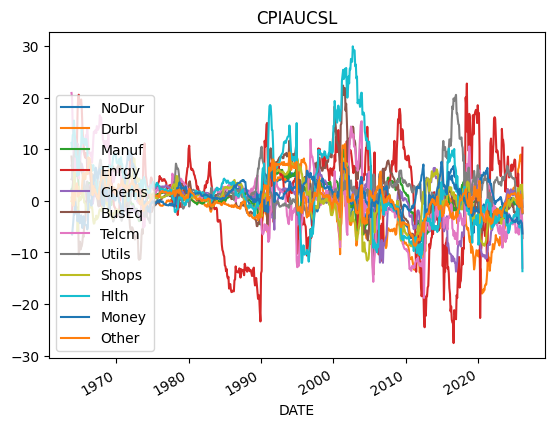

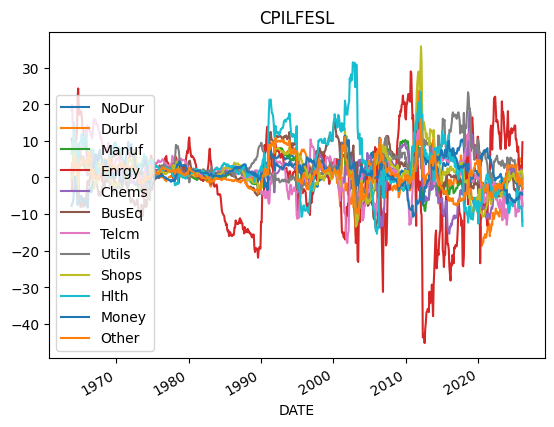

In [25]:
# result.get_beta(factors[0]).plot()
# result.get_beta("US Growth").plot()
import matplotlib.pyplot as plt
for f in factors:
    result.get_beta(f).plot(title=f)
    # plt.ylim(-2, 2)